<a href="https://colab.research.google.com/github/asommula-code/PRODIGY_ML_02/blob/main/PRODIGY_ML_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

import plotly.express as px

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (200, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


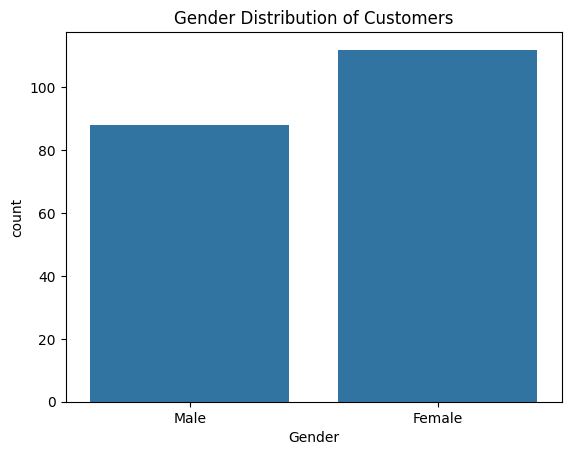

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution of Customers")
plt.show()

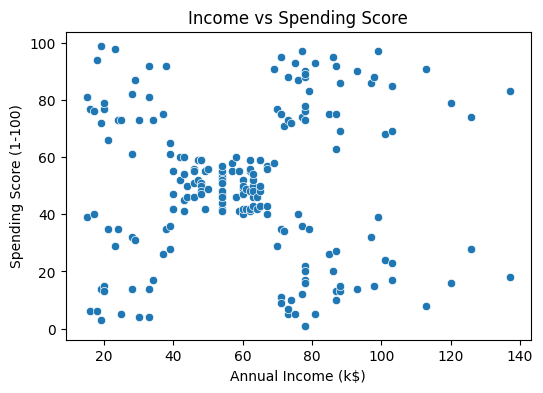

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.title("Income vs Spending Score")
plt.show()

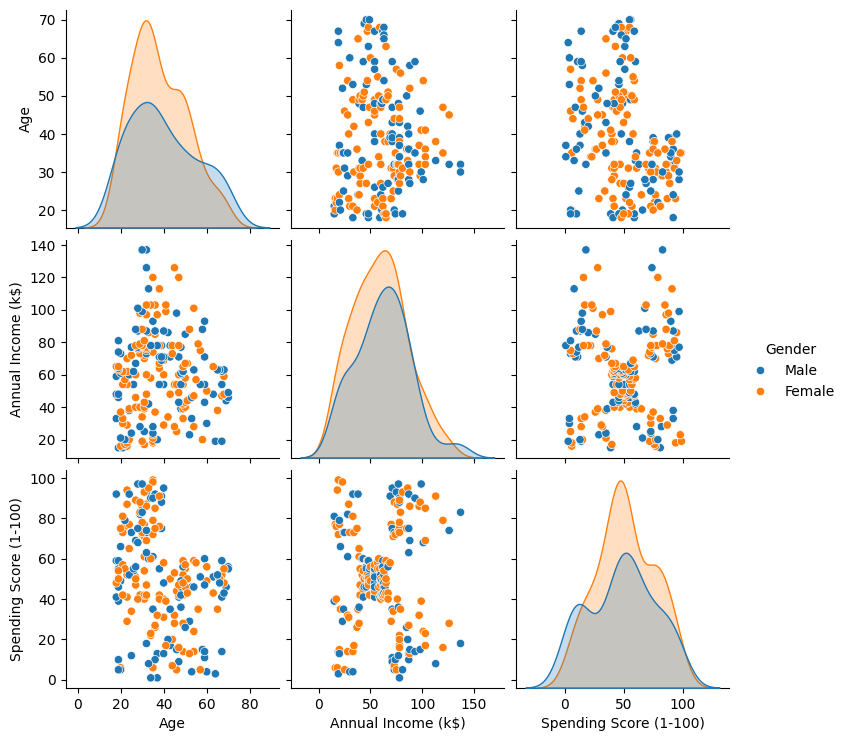

In [ ]:
sns.pairplot(df.drop('CustomerID', axis=1), hue='Gender')
plt.show()

In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X = scaler.fit_transform(features)

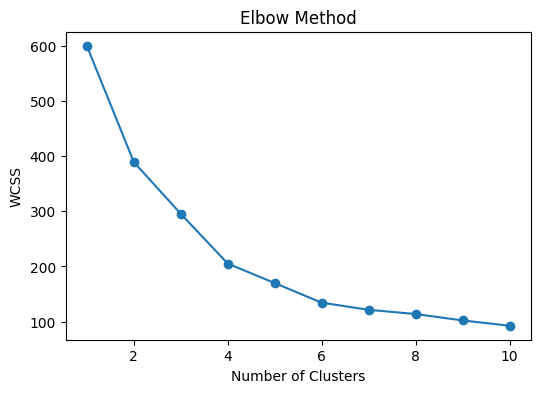

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, Silhouette Score={score:.3f}")

k=2, Silhouette Score=0.335
k=3, Silhouette Score=0.358
k=4, Silhouette Score=0.404
k=5, Silhouette Score=0.408
k=6, Silhouette Score=0.431
k=7, Silhouette Score=0.410
k=8, Silhouette Score=0.367
k=9, Silhouette Score=0.374
k=10, Silhouette Score=0.362


In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,2
1,2,1,21,15,81,2
2,3,0,20,16,6,3
3,4,0,23,16,77,2
4,5,0,31,17,40,2


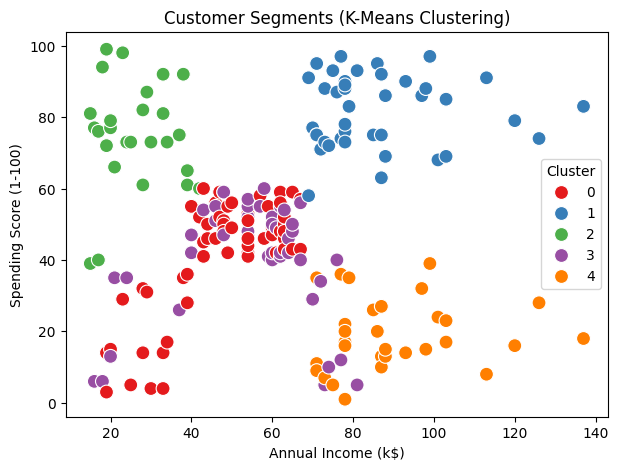

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("Customer Segments (K-Means Clustering)")
plt.show()

In [ ]:
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster',
    title="3D Customer Segmentation"
)

fig.show()

In [ ]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
cluster_summary

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,68.775862,0.431034,55.275862,47.620690,41.706897
1,161.025000,0.450000,32.875000,86.100000,81.525000
2,23.461538,0.423077,25.769231,26.115385,74.846154
3,86.377778,0.400000,26.733333,54.311111,40.911111
4,166.870968,0.516129,44.387097,89.774194,18.483871


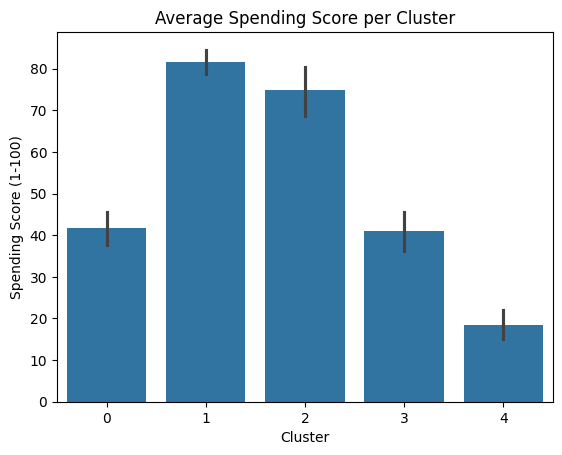

In [ ]:
sns.barplot(x=df['Cluster'], y=df['Spending Score (1-100)'])
plt.title("Average Spending Score per Cluster")
plt.show()